In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

import sys
import os
sys.path.append(os.path.abspath(".."))
import utils.plot_utils as pu

In [ ]:
# Importing wine data set and standardizing it for pca transformation
df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data', header=None)

X, y = df_wine.iloc[:,1:].values, df_wine.iloc[:,0].values
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.8,stratify=y,random_state=0)

sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

### **PCA Implementation**

In [ ]:
# PCA using Numpy
# Creating covariance matrix using which then generate eigenvectors and eigenvalues
cov_mat = np.cov(X_train_std.T)
eigen_val, eigen_vec = np.linalg.eigh(cov_mat)

total = sum(eigen_val)
var_ratio = [(x/total) for x in sorted(eigen_val, reverse=True)]
cum_var_ratio = np.cumsum(var_ratio)

plt.bar(range(1, len(eigen_val)+1), var_ratio, align="center", label="Variance Expense Ratio")
plt.step(range(1, len(eigen_val)+1), cum_var_ratio, where="mid", label="Cumulative Variance Expense Ratio")

plt.xlabel("Principal Component Index")
plt.ylabel("Explained Variance Ratio")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# Converting training dataset to pca 
idx = np.argsort(eigen_val)[::-1]
eigen_val = eigen_val[idx]
eigen_vec = eigen_vec[:,idx]

w = eigen_vec[:,:2]
print("Matrix W : \n", w)

X_train_pca = X_train_std.dot(w)
print(X_train_pca.shape)

In [ ]:
# Loadings
loadings = eigen_vec * np.sqrt(eigen_val)

fig, ax = plt.subplots()
ax.bar(range(13), loadings[:, 0], align='center')
ax.set_ylabel('Loadings for PC 1')
ax.set_xticks(range(13))
ax.set_xticklabels(df_wine.columns[1:], rotation=90)
plt.ylim([-1, 1])
plt.tight_layout()
plt.show()

In [ ]:
# plotting pca transformed training data with labels
colors = ['r', 'b', 'g']
shape = ['o', 's', '^']

for l, c, m in zip(np.unique(y_train), colors, shape):
    plt.scatter(X_train_pca[y_train == l, 0], X_train_pca[y_train == l, 1], c=c, marker=m, label=f"Class {l}")

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# PCA using Sklearn
# sklearn implementation of pca and fitting it into logistic regression
pca = PCA(n_components=2)
lr = LogisticRegression(solver='lbfgs',random_state=1)

X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

lr.fit(X_train_pca, y_train)
pu.plot_decision_regions(X=X_train_pca, y=y_train, model=lr)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

pu.plot_decision_regions(X=X_test_pca, y=y_test, model=lr)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

In [ ]:
# If we want to see explained variance ratio for all PCs instead of reducing dimensions
pca = PCA(n_components=None)
X_train_pca = pca.fit_transform(X_train_std)

pca.explained_variance_ratio_

In [ ]:
# Loadings
sklearn_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
fig, ax = plt.subplots()
ax.bar(range(13), sklearn_loadings[:, 0], align='center')
ax.set_ylabel('Loadings for PC 1')
ax.set_xticks(range(13))
ax.set_xticklabels(df_wine.columns[1:], rotation=90)
plt.ylim([-1, 1])
plt.tight_layout()
plt.show()

### **LDA Implementation**

In [12]:
# LDA without Sklearn in normal Python 
labels = np.unique(y)
np.set_printoptions(precision=3)

mean_vecs = []
for label in labels:
    mean_vecs.append(np.mean(X_train_std[y_train == label], axis=0))
    print(f"Mean Vector {label} : {mean_vecs[label-1]}")

mean_overall = np.mean(X_train_std, axis=0)
print(f"Overall Mean : {mean_overall}")

d = len(mean_overall)
d

Mean Vector 1 : [ 0.916 -0.326  0.289 -0.716  0.457  0.871  0.958 -0.551  0.534  0.213
  0.592  0.697  1.206]
Mean Vector 2 : [-0.893 -0.295 -0.408  0.278 -0.38  -0.055  0.046 -0.04   0.058 -0.823
  0.307  0.301 -0.729]
Mean Vector 3 : [ 0.207  0.845  0.255  0.468  0.005 -0.996 -1.253  0.742 -0.748  0.972
 -1.193 -1.314 -0.398]
Overall Mean : [-2.004e-15 -1.329e-16 -1.537e-15  1.239e-16 -1.642e-16 -7.287e-16
  1.175e-15 -1.123e-15 -4.890e-16  2.439e-16  6.945e-16  1.256e-15
  1.235e-16]


13

Eigen Values : [398.1238 191.5197   0.       0.       0.       0.       0.      -0.
  -0.      -0.      -0.      -0.      -0.    ]


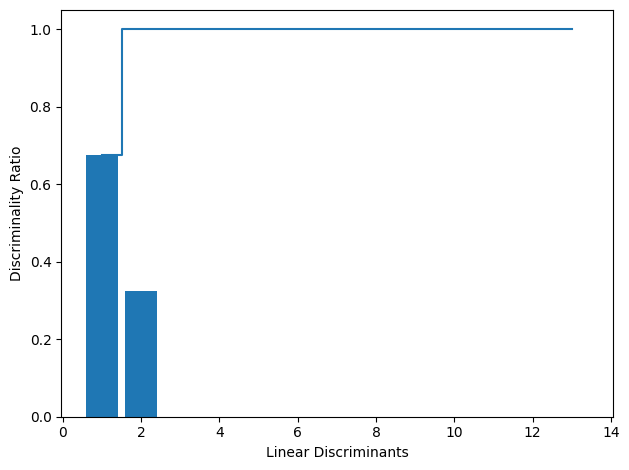

In [31]:
np.set_printoptions(precision=4, suppress=True)

# Within Class Scatter
S_w = np.zeros((d,d))
for label in labels:
    label_scatter = np.cov(X_train_std[y_train==label].T)
    S_w += label_scatter

# Between Class Scatter
S_b = np.zeros((d,d))
for label, mean_vec in enumerate(mean_vecs):
    diff_vec = (mean_vec - mean_overall).reshape(d,1)
    n = X_train_std[y_train==label+1].shape[0]
    
    label_scatter = n * (diff_vec.dot(diff_vec.T))
    S_b += label_scatter

# Extracting Eigen Vectors and Eigen Values
from scipy.linalg import eig

eigen_val, eigen_vec = eig(S_b, S_w)
idx = np.argsort(eigen_val.real)[::-1]

eigen_val = eigen_val.real[idx]
eigen_vec = eigen_vec.real[:, idx]
print(f"Eigen Values : {eigen_val}")

# Discriminality Ratio
total = sum(eigen_val)
discr = [(i/total) for i in eigen_val]
cum_discr = np.cumsum(discr)

plt.bar(range(1,14), discr, align="center", label="Individual Discriminality")
plt.step(range(1,14), cum_discr, where="mid", label="Cumulative Discriminality")
plt.xlabel("Linear Discriminants")
plt.ylabel("Discriminality Ratio")
plt.tight_layout()
plt.show()


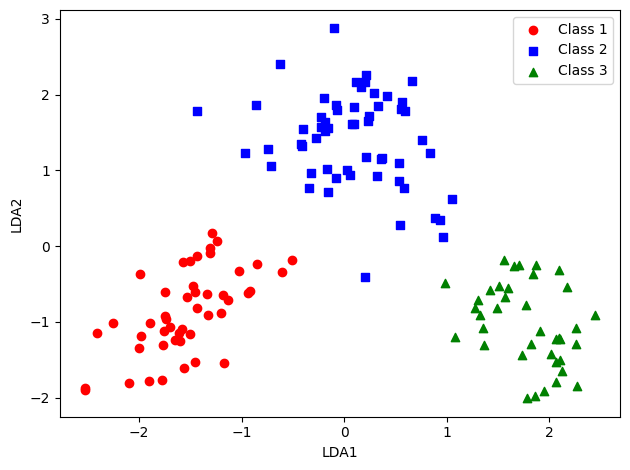

In [33]:
w = eigen_vec[:,:2]
X_train_lda = X_train_std.dot(w)

# plotting pca transformed training data with labels
colors = ['r', 'b', 'g']
shape = ['o', 's', '^']

for l, c, m in zip(np.unique(y_train), colors, shape):
    plt.scatter(X_train_lda[y_train == l, 0], X_train_lda[y_train == l, 1], c=c, marker=m, label=f"Class {l}")

plt.xlabel("LDA1")
plt.ylabel("LDA2")
plt.legend()
plt.tight_layout()
plt.show()


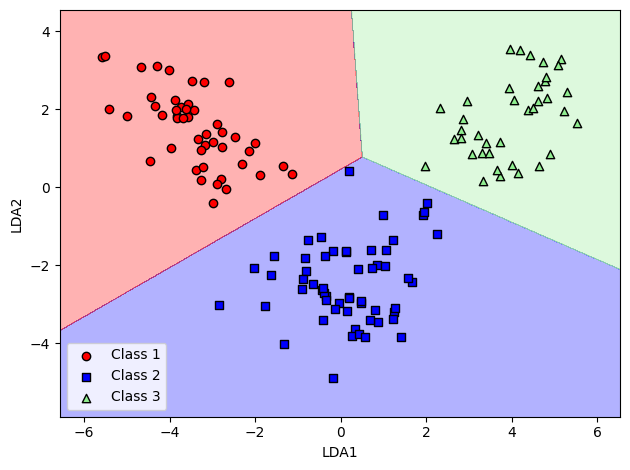

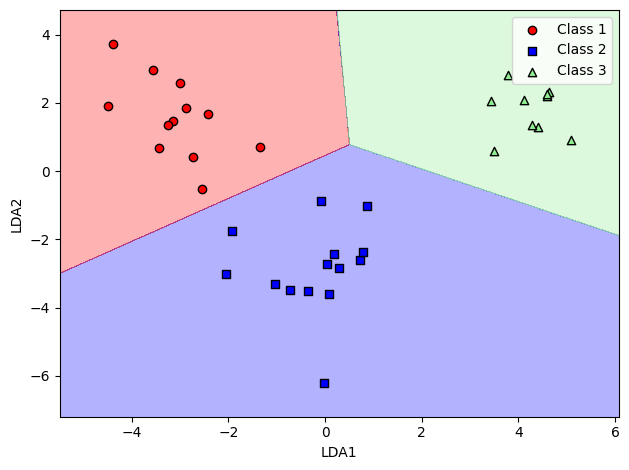

In [35]:
# LDA using sklearn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(X_train_std, y_train)
X_test_lda = lda.transform(X_test_std)

lr = LogisticRegression(solver='lbfgs', random_state=1)
lr.fit(X_train_lda, y_train)

lr.fit(X_train_lda, y_train)
pu.plot_decision_regions(X=X_train_lda, y=y_train, model=lr)
plt.xlabel('LDA1')
plt.ylabel('LDA2')
plt.tight_layout()
plt.show()

pu.plot_decision_regions(X=X_test_lda, y=y_test, model=lr)
plt.xlabel('LDA1')
plt.ylabel('LDA2')
plt.tight_layout()
plt.show()